# Data Preprocessing

In [1]:
from data.preprocessing import load_parquet_splits, preprocess_splits

Let's start by loading the GoEmotions dataset.

In [2]:
df_train, df_validation, df_test = load_parquet_splits()
df_train


C:\Users\jack6\.conda\envs\go_emotions\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,text,labels,id
0,My favourite food is anything I didn't have to...,[27],eebbqej
1,"Now if he does off himself, everyone will thin...",[27],ed00q6i
2,WHY THE FUCK IS BAYLESS ISOING,[2],eezlygj
3,To make her feel threatened,[14],ed7ypvh
4,Dirty Southern Wankers,[3],ed0bdzj
...,...,...,...
43405,Added you mate well I’ve just got the bow and ...,[18],edsb738
43406,Always thought that was funny but is it a refe...,[6],ee7fdou
43407,What are you talking about? Anything bad that ...,[3],efgbhks
43408,"More like a baptism, with sexy results!",[13],ed1naf8


The raw dataset has multiple labels for some of the entries. The scope of this project does not include multi-label classification, so the first label will be assigned to the entry in such cases. Also, a `sentiment_label` column is added to specify if each emotion is positive/negative/neutral. This will be needed for the hierarchical models later on. An additional `ekman_label` column is added, not out of necessity but for analysis later on.

In [3]:
df_train, df_validation, df_test = preprocess_splits(df_train, df_validation, df_test)
df_train

,text,id,label,sentiment_label,ekman_label
0,My favourite food is anything I didn't have to...,eebbqej,27,2,5
1,"Now if he does off himself, everyone will thin...",ed00q6i,27,2,5
2,WHY THE FUCK IS BAYLESS ISOING,eezlygj,2,1,0
3,To make her feel threatened,ed7ypvh,14,1,2
4,Dirty Southern Wankers,ed0bdzj,3,1,0
...,...,...,...,...,...
43405,Added you mate well I’ve just got the bow and ...,edsb738,18,0,3
43406,Always thought that was funny but is it a refe...,ee7fdou,6,2,5
43407,What are you talking about? Anything bad that ...,efgbhks,3,1,0
43408,"More like a baptism, with sexy results!",ed1naf8,13,0,3


# Flat Classifier

For the first part of this project, we will use the pretrained DistilBERT uncased model with a 28-output classification head (one for each emotion). It is referred to as the "flat" model because the output head is merely just a flat fully connected layer.

### Training

In [4]:
from data.dataset import df_to_dataset, tokenize_datasets
from training.train_flat import train_flat

We will use the HuggingFace Trainer object to train our flat model. Thus, our DataFrame objects need to be converted to HuggingFace Datasets.

In [5]:
ds_train, ds_val, ds_test = df_to_dataset(df_train, df_validation, df_test)

Next, we have to tokenize (convert raw text into token IDs and attention masks) the datasets.

In [6]:
ds_train, ds_val, ds_test = tokenize_datasets(ds_train, ds_val, ds_test)

Map: 100%|██████████| 5427/5427 [00:00<00:00, 35724.36 examples/s]


Now we can train the flat classifier. It is the DistilBERT base uncased model plus an additional linear head of 28 output neurons, corresponding to the 28 emotion classes.

In [7]:
train_flat(ds_train, ds_val)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\jack6\OneDrive\Desktop\GitHub\DistilBERT-Emotion-Classification\training\train_flat.py:75: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(model=model,


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.456800,1.427627,0.573535,0.417635
2,1.309400,1.379534,0.578142,0.452396
3,1.126600,1.409942,0.579432,0.461552
4,0.932400,1.475019,0.571323,0.450909
5,0.813700,1.521524,0.568743,0.451020


### Testing

In [ ]:
from training.train_flat import test_flat

Let's see how the flat classifier performed on the test set.

In [7]:
test_flat(ds_test=ds_test)

Testing: 100%|██████████| 340/340 [00:09<00:00, 35.35it/s]

Accuracy: 0.5745347337387139
Macro F1: 0.4485521837608128


### Inspecting

In [2]:
from analysis.visualize_weights import *

Now, for the main part of the project, let's see how the model actually "thinks" about each emotion when making predictions. We can do this by inspecting the weights of the classifier head. Let's start by plotting the cosine similarity between every pair of classifier weights. We can expect the cosine similarity to be higher (brighter square) between similar emotions.

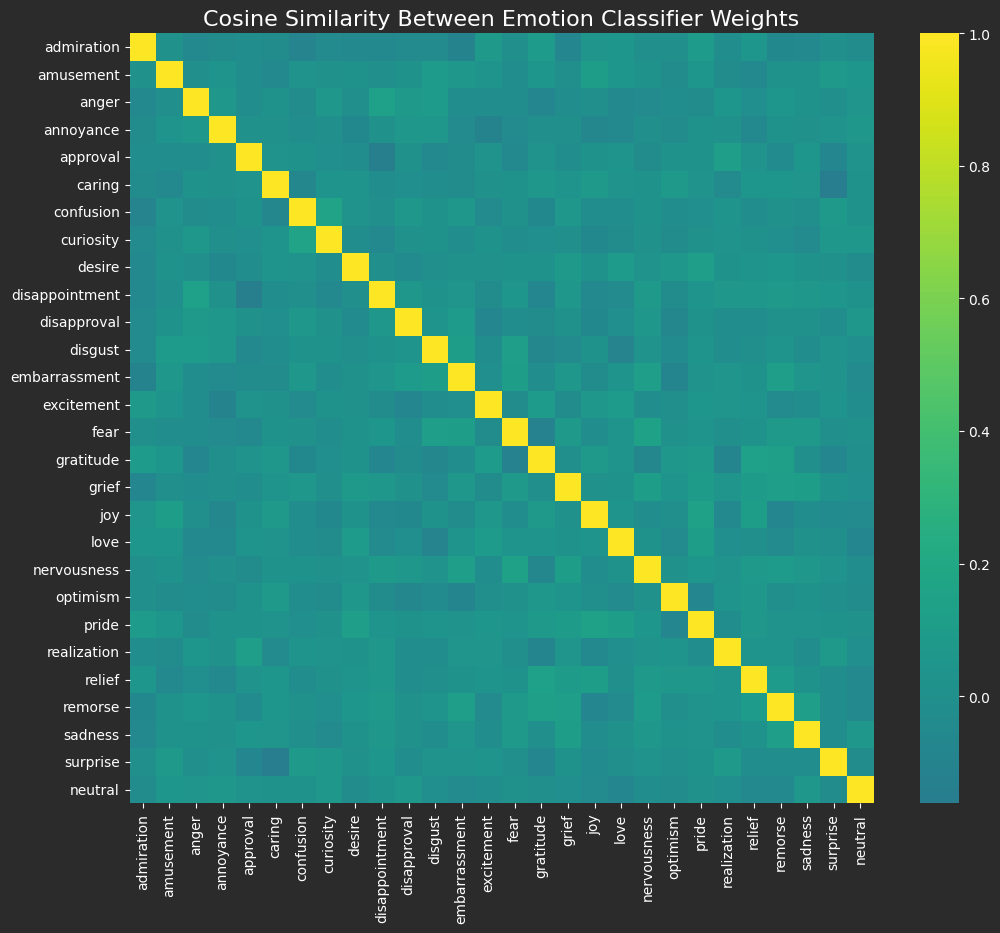

In [3]:
plot_cosine_similarity()

Let's inspect the